GPs are constantly changing, and the rate of change depends on the orbit of the satellite being analysed; according to Space-Track, GNSS will have GPs that remain exactly valid for a few weeks, while Starlink's (in low orbit) remain exactly valid only for a few days. The amount of time they remain approximately valid is not described.

As a visualization only, we can experiment and check how the trajectories change if this observation happened **today** and we used today's GPs vs. GPs from X days ago.

In [19]:
# to fix the value for today -- RUN ONCE!
TODAY = datetime.now()

## A. Starlink

#### Today

In [3]:
import numpy as np
import pickle
from astropy import units as u
from skyfield.api import wgs84
from datetime import datetime,timedelta
import CheckSatellites_packages as CS
import matplotlib.pyplot as plt

In [22]:
params = {
    # observation characteristics
    "block": int(TODAY.timestamp()),
    "path_katdal": "../results_calibration/1551055211/katdal_info.p",
    "MK_lat": (-30.0) + (-42.0)/60 + (-39.8)/3600,
    "MK_lon": (21.0) + (26.0)/60 + (38.00)/3600,
    "MK_el": 1086.6,
    # satellite retrieval
    "group": "starlink",
    "ST_user": "mariavitoria.ab@gmail.com",  # <-- necessary for historical only
    "ST_password": "Spacetrack.MeerKLASS",  # <-- necessary for historical only
    # angles
    "angle_cutoff": 15,
    "angle_labels": 1,
    # number of timestamps
    "Nt_check": 100,
    "Nt_plot": None,
}

SATCAT for 'starlink' at 2026-09-17 already exist!
Number of 'starlink' satellites: 11120.
GPs for 'starlink' at 2026-09-17 already exist!
Number of 'starlink' satellites: 11120.
Checking satellites above the horizon...
	Number of satellites above horizon: 4727
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 6393
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 303
	Number of satellites removed: 4424


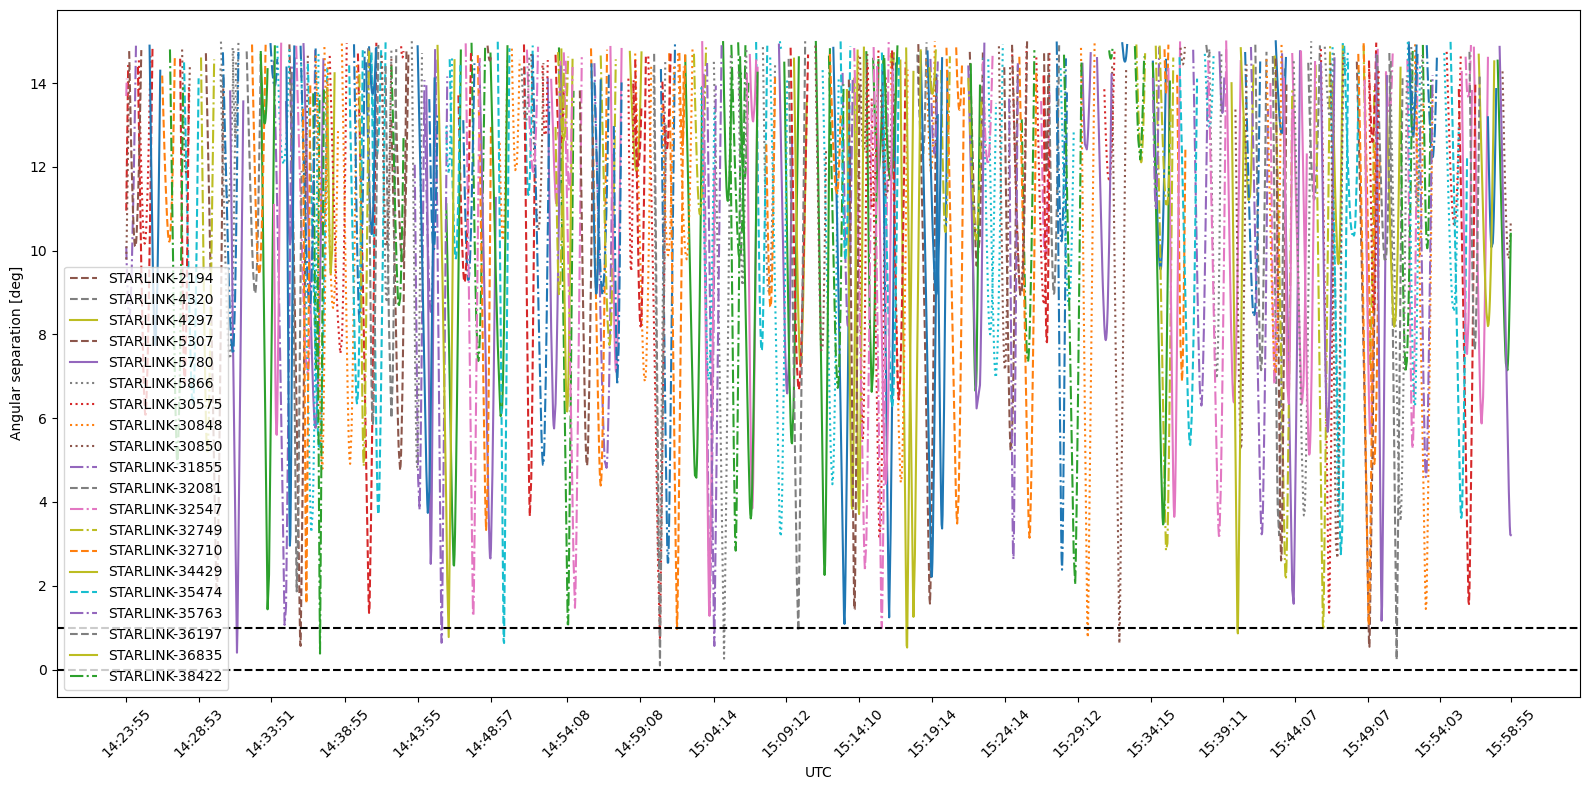

In [23]:
# retrieve block properties -- using 1551055211 for example
katdal = pickle.load(open(params["path_katdal"],"rb"),encoding="latin1")
MK_times = (katdal["nd_s0"] + params["block"]) * u.second
MK_location = wgs84.latlon(params["MK_lat"], params["MK_lon"], params["MK_el"])
MK_az = np.array(katdal["nd_s0_coords"][0])
MK_alt = np.array(katdal["nd_s0_coords"][1])

# perform pipeline for TODAY
sats = CS.retrieve_sats(params)
sats2 = CS.check_above_horizon(sats, MK_times, MK_location, params)
sats3 = CS.check_within_cutoff(sats2, MK_times, MK_az, MK_alt, MK_location, params)
angles = CS.plot_angular_separations(sats3, MK_times, MK_az, MK_alt, MK_location, params)

#### 10 days ago

So as to not overuse Space-Track's pipeline for satellite retrieval, we will just check the satellites that we know are in the final `sats3` dictionary in the previous section. As a result of retrieving 10 days earlier, we get some satellites that don't appear anymore on the graph, and the rest is a bit shifted.

SATCAT for 'starlink' at 2026-09-07 already exist!
Number of 'starlink' satellites: 303.
Retrieving GPs for 'starlink' at 2026-09-07...
Number of 'starlink' satellites: 296.
Checking satellites above the horizon...
	Number of satellites above horizon: 296
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 0
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 244
	Number of satellites removed: 52


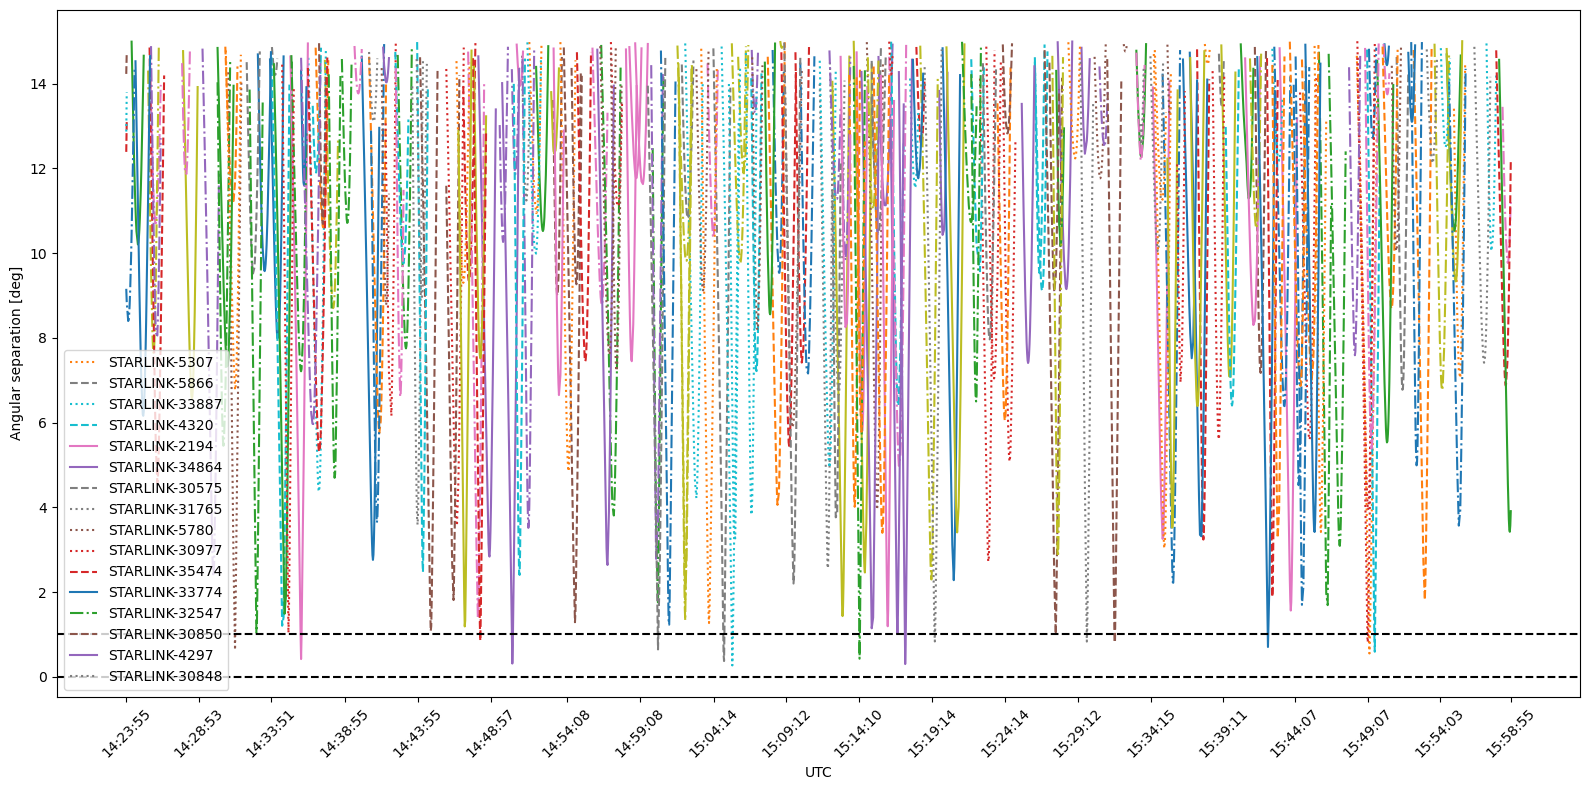

Only in anglesB: STARLINK-11155
Only in anglesB: STARLINK-11078
Only in anglesB: STARLINK-11076


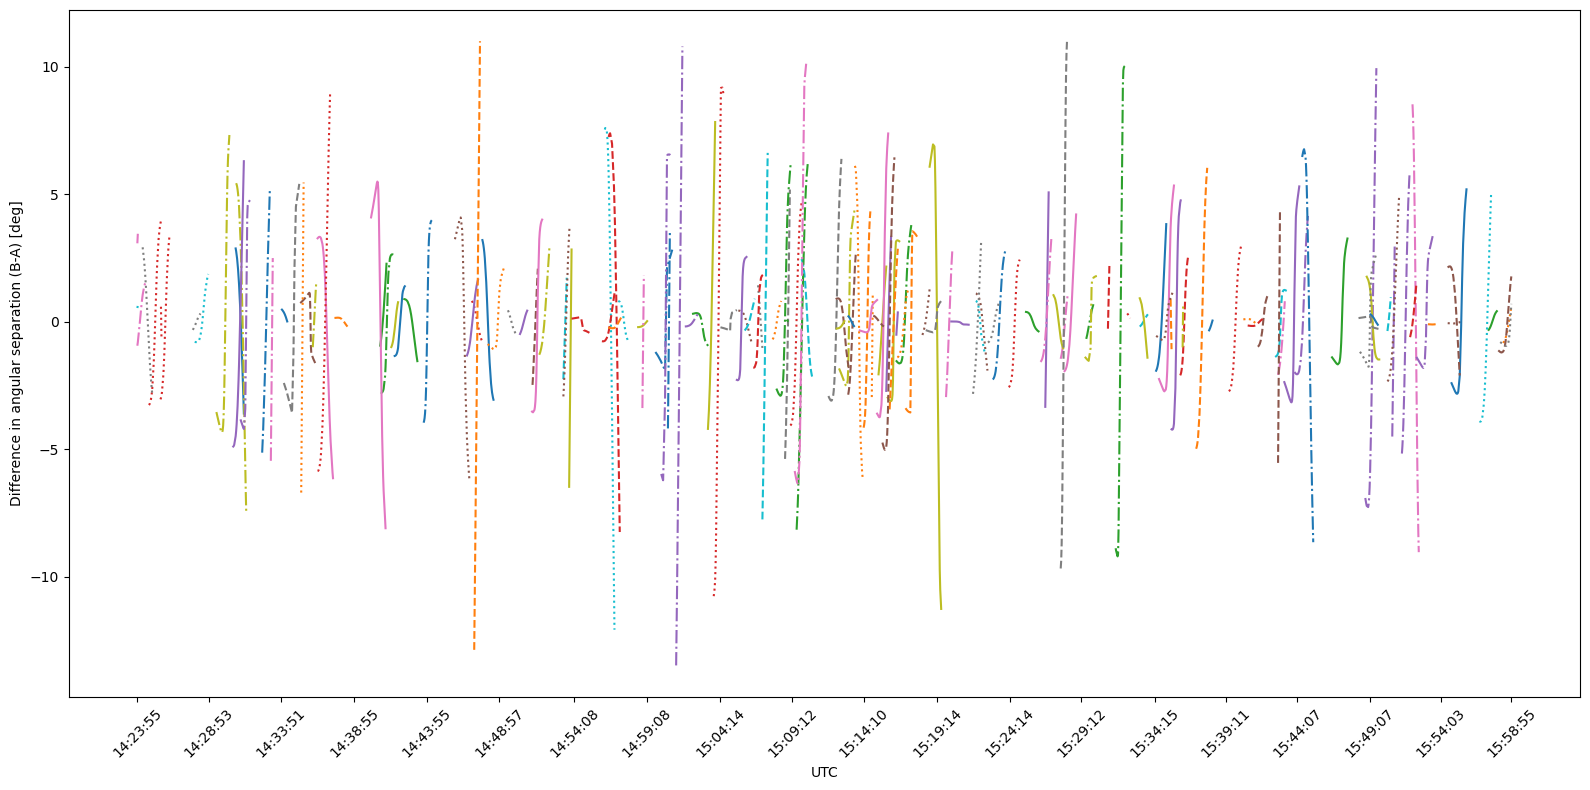

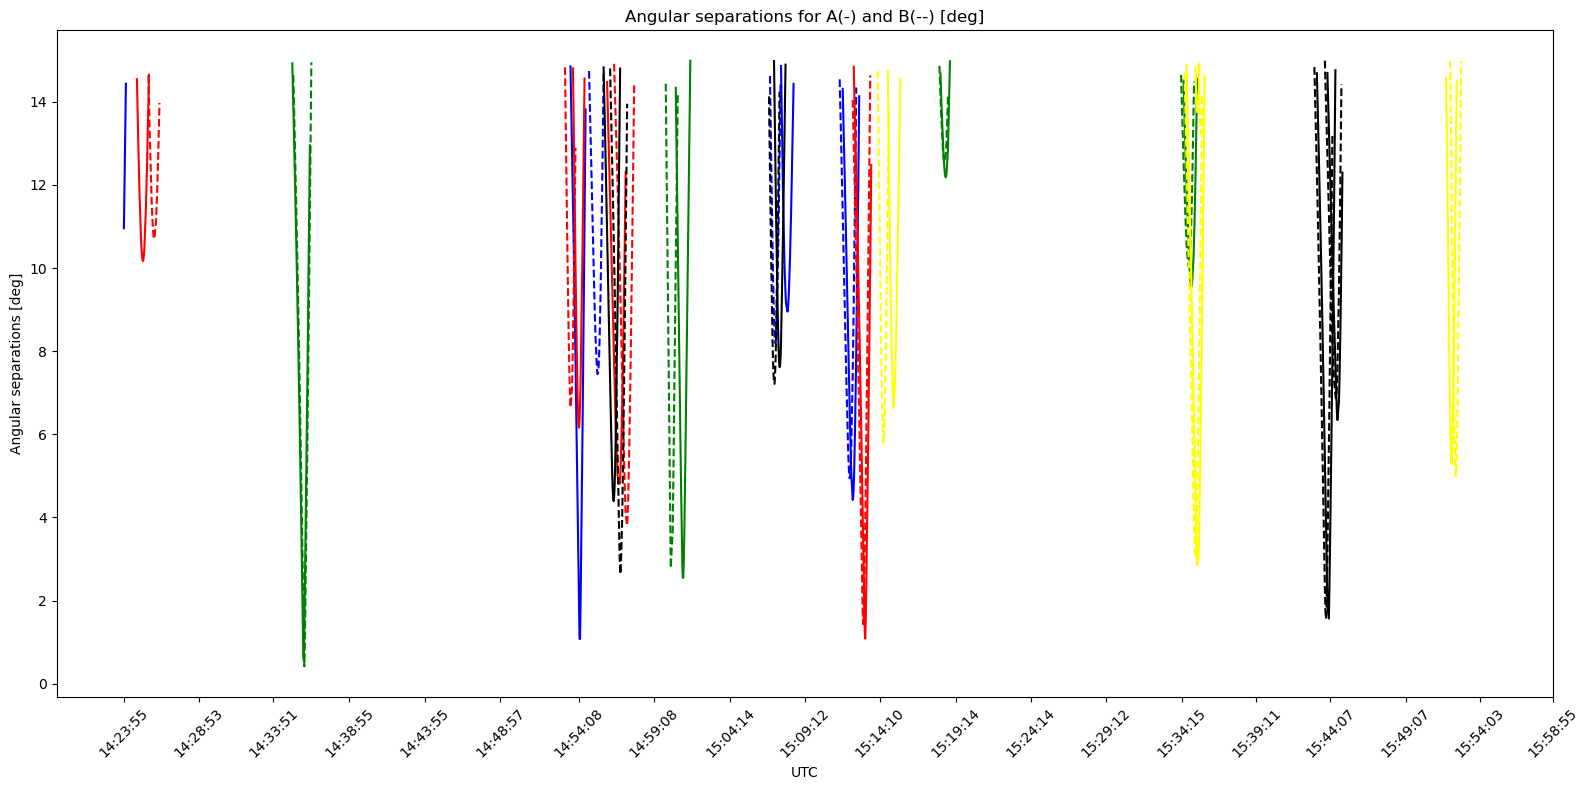

In [24]:
# generating information for 10 days
N = 10
source_older = int((TODAY - timedelta(days=N)).timestamp())
sats_older = CS.retrieve_sats(params,source_older,sat_names=set(sats3.keys()))
sats_older2 = CS.check_above_horizon(sats_older, MK_times, MK_location, params)
sats_older3 = CS.check_within_cutoff(sats_older2, MK_times, MK_az, MK_alt, MK_location, params)
angles_older = CS.plot_angular_separations(sats_older3, MK_times, MK_az, MK_alt, MK_location, params)
angles_diff = CS.plot_different_sources(angles, angles_older, MK_times, params)
CS.plot_different_sources2(angles, angles_older, MK_times, params)

#### 30 days ago

Now the satellites are very shifted, and several went in/out of the window.

SATCAT for 'starlink' at 2026-08-18 already exist!
Number of 'starlink' satellites: 295.
Retrieving GPs for 'starlink' at 2026-08-18...
Number of 'starlink' satellites: 293.
Checking satellites above the horizon...
	Number of satellites above horizon: 292
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 1
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 166
	Number of satellites removed: 126


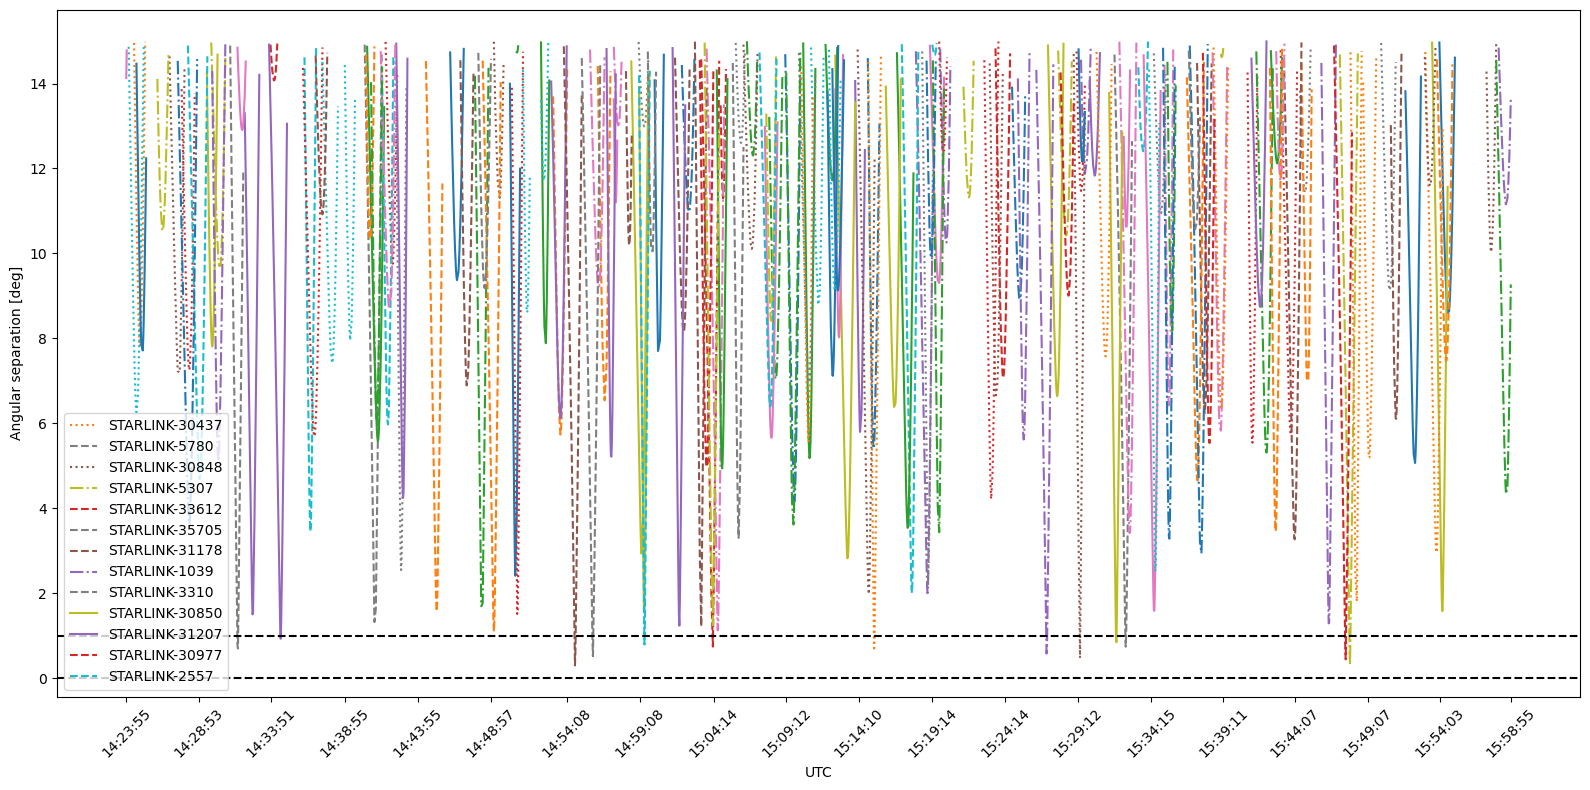

Only in anglesB: STARLINK-11271
Only in anglesB: STARLINK-30881
Only in anglesB: STARLINK-11076
Only in anglesB: STARLINK-11155
Only in anglesB: STARLINK-32323
Only in anglesB: STARLINK-35158
Only in anglesB: STARLINK-33783
Only in anglesB: STARLINK-11116
Only in anglesB: STARLINK-6152
Only in anglesB: STARLINK-31651
Only in anglesB: STARLINK-11730
Only in anglesB: STARLINK-11619
Only in anglesB: STARLINK-31529
Only in anglesB: STARLINK-30564
Only in anglesB: STARLINK-31986
Only in anglesB: STARLINK-31918


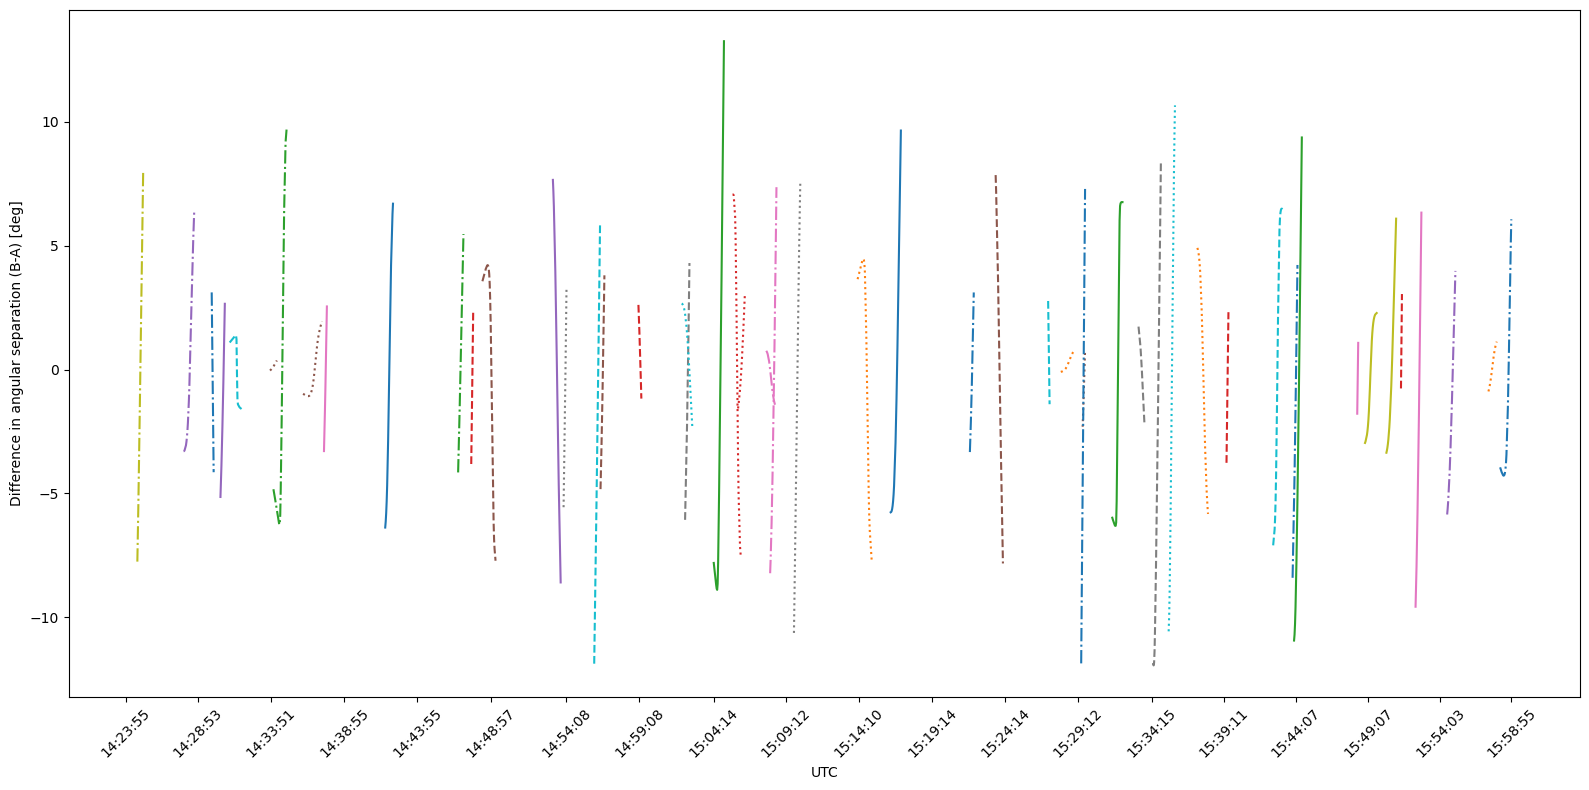

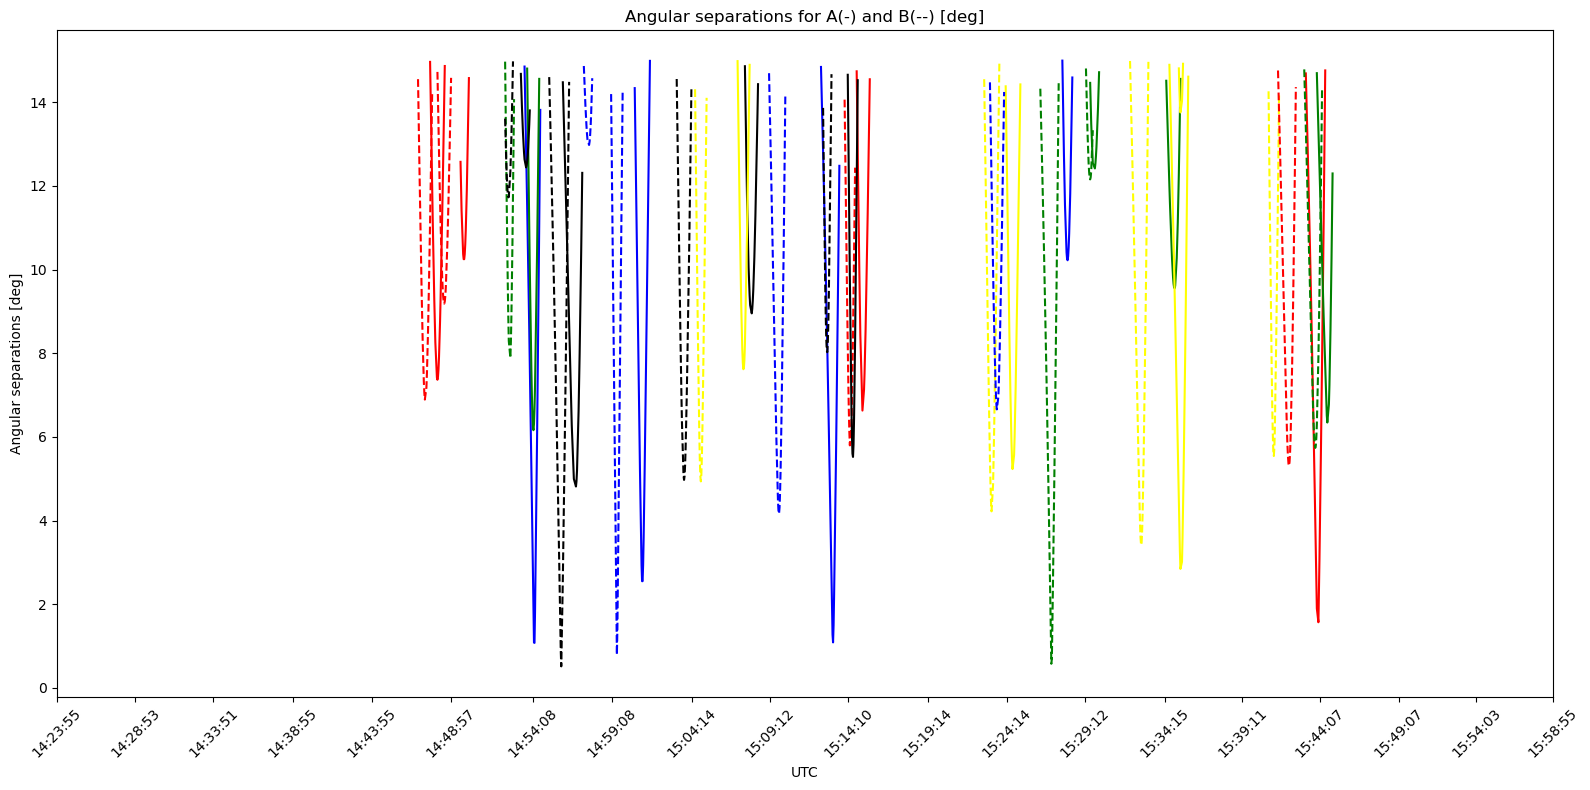

In [25]:
# generating information for 10 days
N = 30
source_older = int((TODAY - timedelta(days=N)).timestamp())
sats_older = CS.retrieve_sats(params,source_older,sat_names=set(sats3.keys()))
sats_older2 = CS.check_above_horizon(sats_older, MK_times, MK_location, params)
sats_older3 = CS.check_within_cutoff(sats_older2, MK_times, MK_az, MK_alt, MK_location, params)
angles_older = CS.plot_angular_separations(sats_older3, MK_times, MK_az, MK_alt, MK_location, params)
angles_diff = CS.plot_different_sources(angles, angles_older, MK_times, params)
CS.plot_different_sources2(angles, angles_older, MK_times, params)

#### 90 days ago

Useless to predict positions at all, most of the satellites go out of frame and those that stay are far from where they were.

SATCAT for 'starlink' at 2026-06-19 already exist!
Number of 'starlink' satellites: 293.
Retrieving GPs for 'starlink' at 2026-06-19...
Number of 'starlink' satellites: 293.
Checking satellites above the horizon...
	Number of satellites above horizon: 286
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 7
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 89
	Number of satellites removed: 197


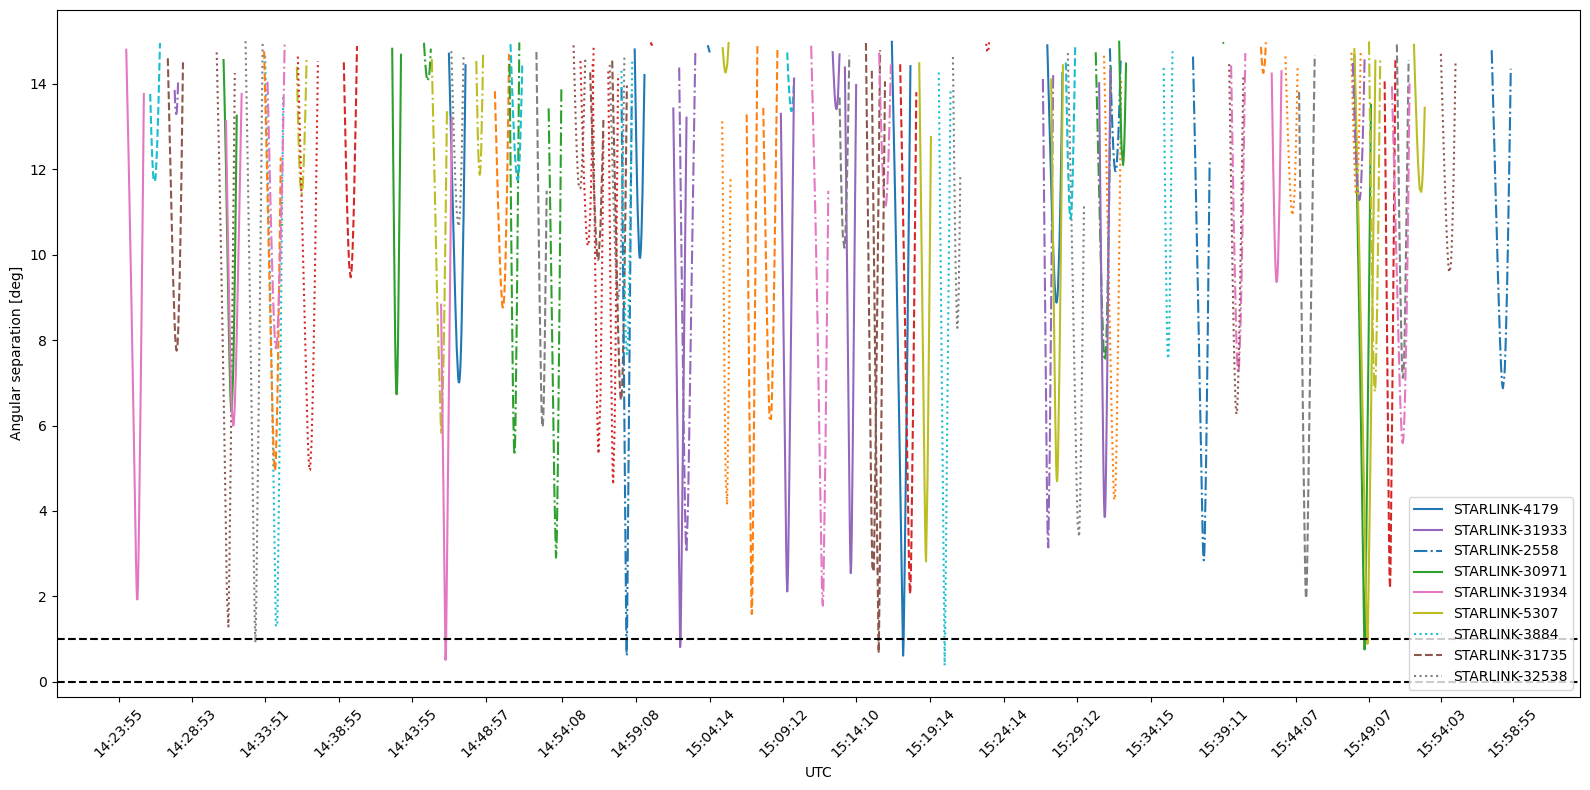

Only in anglesB: STARLINK-4179
Only in anglesB: STARLINK-30283
Only in anglesB: STARLINK-31933
Only in anglesB: STARLINK-30881
Only in anglesB: STARLINK-31597
Only in anglesB: STARLINK-32323
Only in anglesB: STARLINK-35678
Only in anglesB: STARLINK-33886
Only in anglesB: STARLINK-31767
Only in anglesB: STARLINK-32950
Only in anglesB: STARLINK-35588
Only in anglesB: STARLINK-35833
Only in anglesB: STARLINK-30071
Only in anglesB: STARLINK-31899
Only in anglesB: STARLINK-6152
Only in anglesB: STARLINK-31651
Only in anglesB: STARLINK-30877
Only in anglesB: STARLINK-6142
Only in anglesB: STARLINK-30854
Only in anglesB: STARLINK-3874
Only in anglesB: STARLINK-31716
Only in anglesB: STARLINK-35665
Only in anglesB: STARLINK-5477
Only in anglesB: STARLINK-5202
Only in anglesB: STARLINK-5257
Only in anglesB: STARLINK-11116
Only in anglesB: STARLINK-3914
Only in anglesB: STARLINK-31529
Only in anglesB: STARLINK-4551


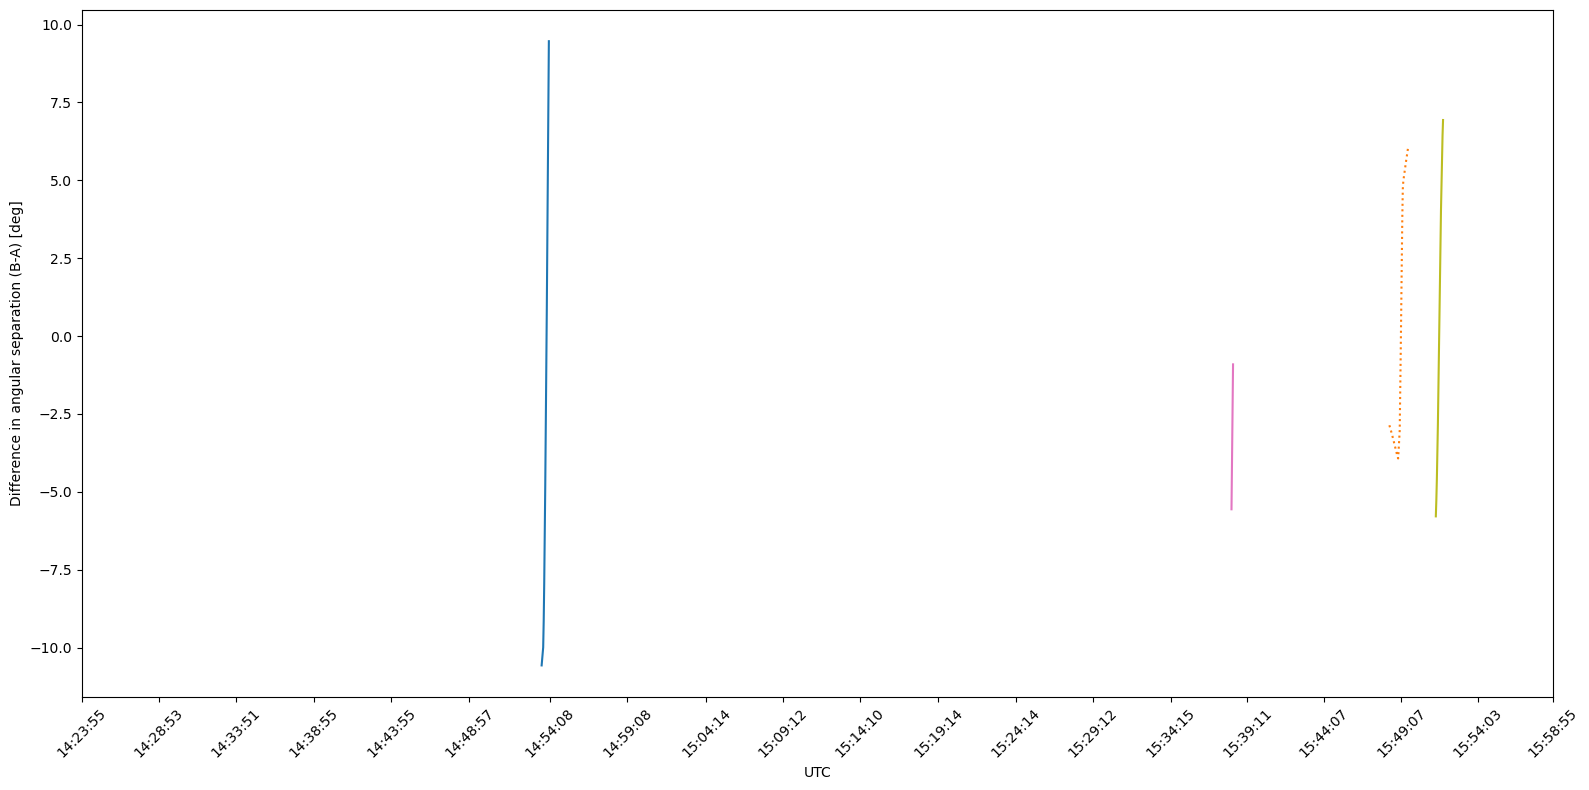

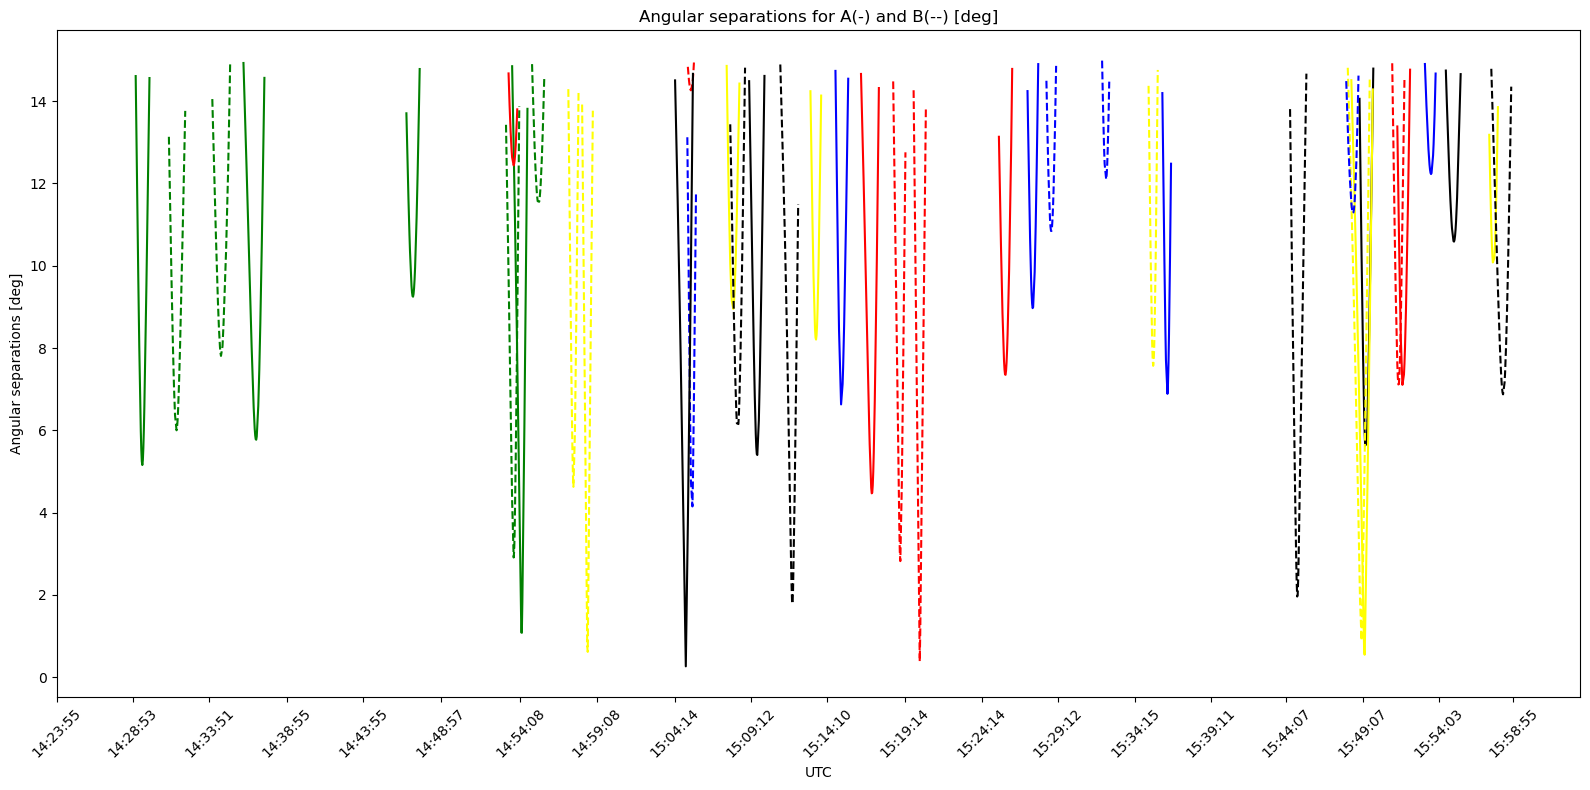

In [26]:
# generating information for 10 days
N = 90
source_older = int((TODAY - timedelta(days=N)).timestamp())
sats_older = CS.retrieve_sats(params,source_older,sat_names=set(sats3.keys()))
sats_older2 = CS.check_above_horizon(sats_older, MK_times, MK_location, params)
sats_older3 = CS.check_within_cutoff(sats_older2, MK_times, MK_az, MK_alt, MK_location, params)
angles_older = CS.plot_angular_separations(sats_older3, MK_times, MK_az, MK_alt, MK_location, params)
angles_diff = CS.plot_different_sources(angles, angles_older, MK_times, params)
CS.plot_different_sources2(angles, angles_older, MK_times, params)

## B. GNSS

Overall, GNSS remain more reliable.

#### Today

In [27]:
params = {
    # observation characteristics
    "block": int(TODAY.timestamp()),
    "path_katdal": "../results_calibration/1551055211/katdal_info.p",
    "MK_lat": (-30.0) + (-42.0)/60 + (-39.8)/3600,
    "MK_lon": (21.0) + (26.0)/60 + (38.00)/3600,
    "MK_el": 1086.6,
    # satellite retrieval
    "group": "gnss",
    "ST_user": "mariavitoria.ab@gmail.com",  # <-- necessary for historical only
    "ST_password": "Spacetrack.MeerKLASS",  # <-- necessary for historical only
    # angles
    "angle_cutoff": 15,
    "angle_labels": 1,
    # number of timestamps
    "Nt_check": 100,
    "Nt_plot": None,
}

Source is from the present/future, fetching today's GPs!
GPs for 'gnss' at 2026-09-17 already exist!
Number of 'gnss' satellites: 165.
Checking satellites above the horizon...
	Number of satellites above horizon: 79
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 86
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 6
	Number of satellites removed: 73


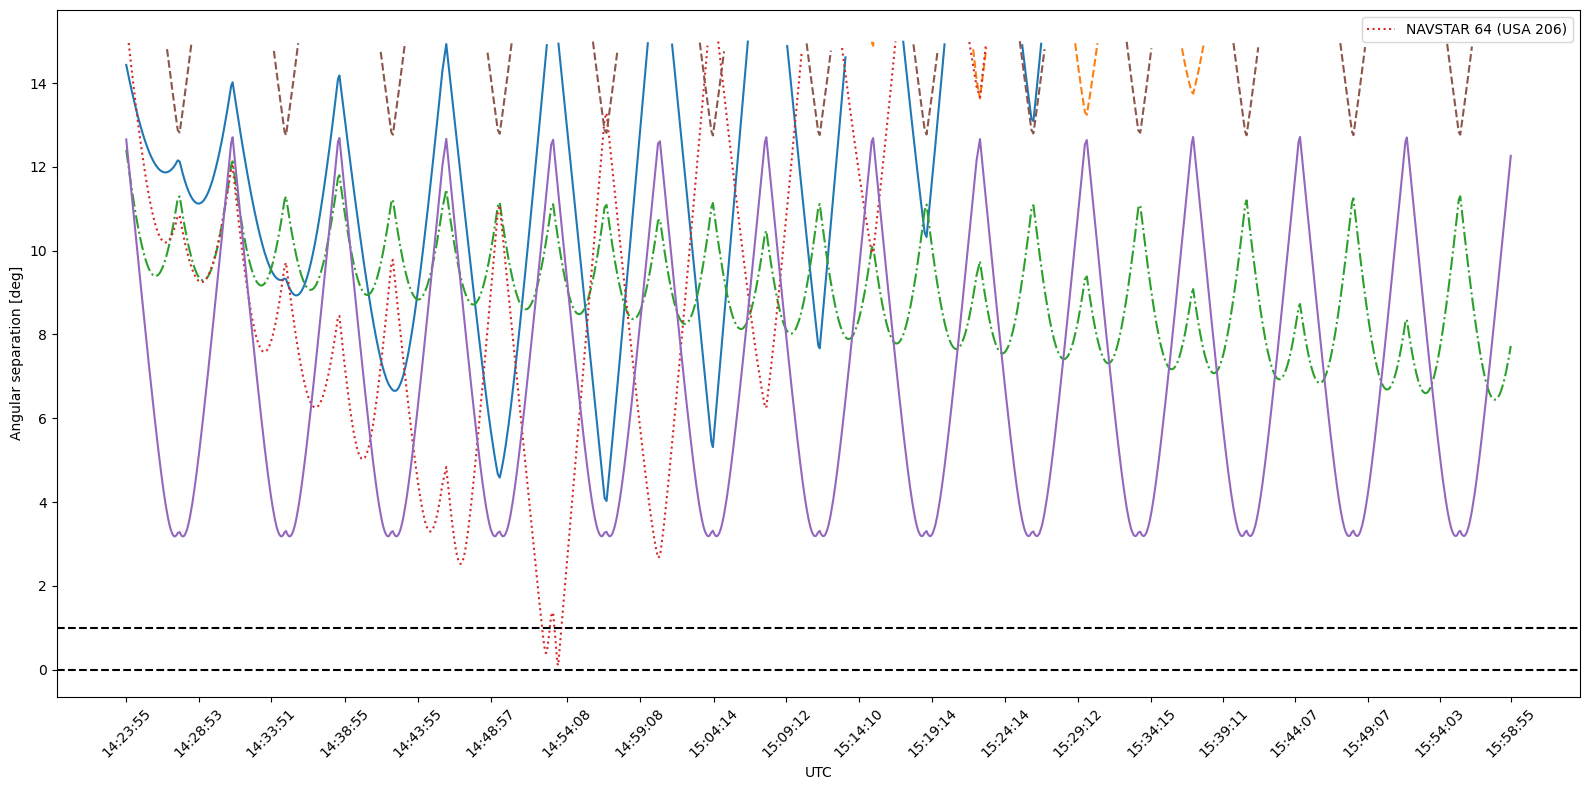

In [44]:
# perform pipeline for TODAY
sats = CS.retrieve_sats(params)
sats2 = CS.check_above_horizon(sats, MK_times, MK_location, params)
sats3 = CS.check_within_cutoff(sats2, MK_times, MK_az, MK_alt, MK_location, params)
angles = CS.plot_angular_separations(sats3, MK_times, MK_az, MK_alt, MK_location, params)

#### 10 days

Within 10 days GNSS remain extremely reliable.

SATCAT for 'gnss' already exist!
Number of 'gnss' satellites: 173.
GPs for 'gnss' at 2026-09-07 already exist!
Number of 'gnss' satellites: 163.
Checking satellites above the horizon...
	Number of satellites above horizon: 80
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 83
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 6
	Number of satellites removed: 74


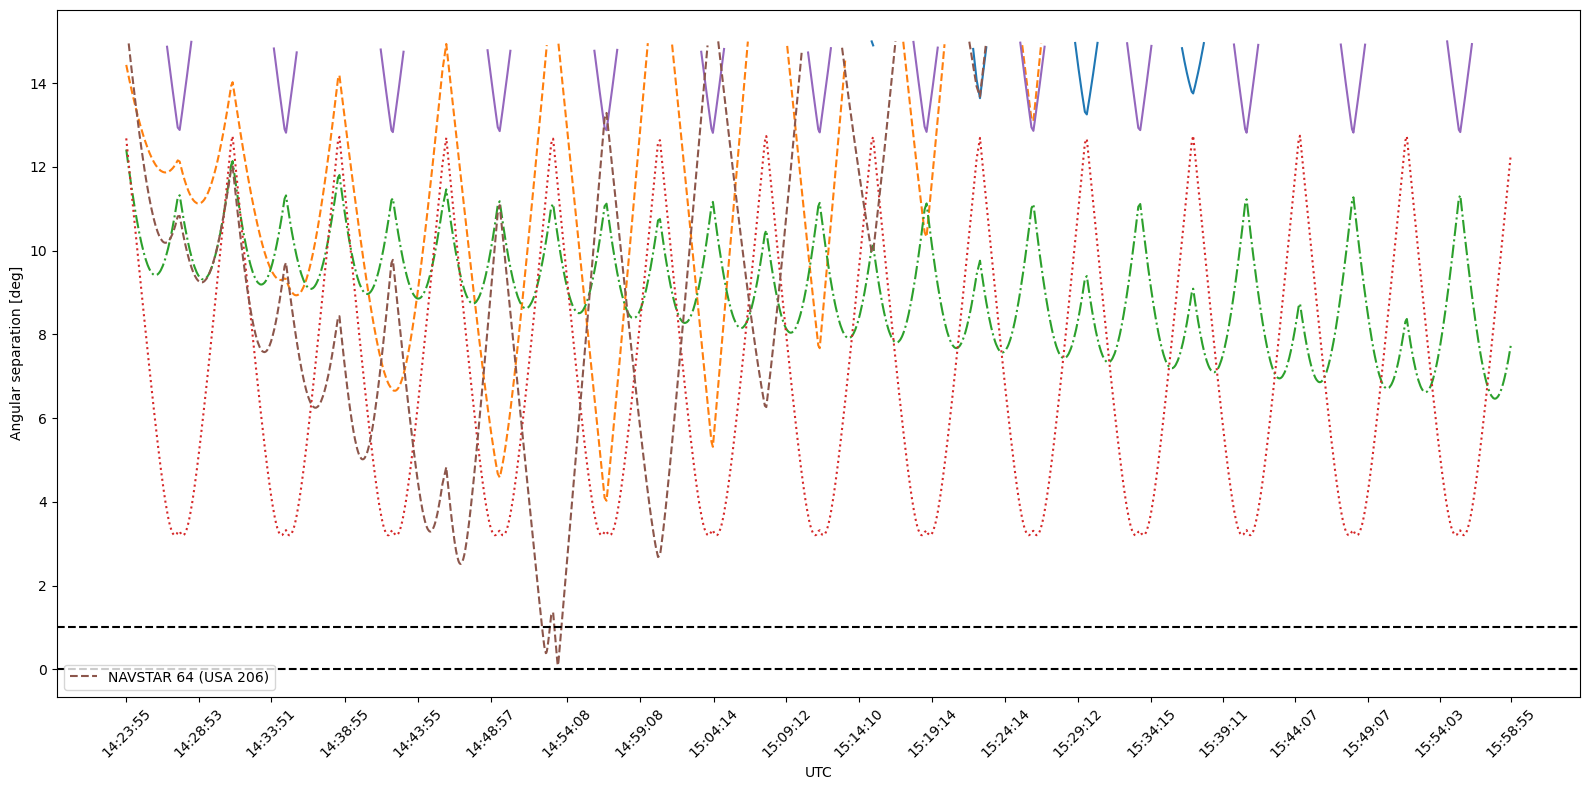

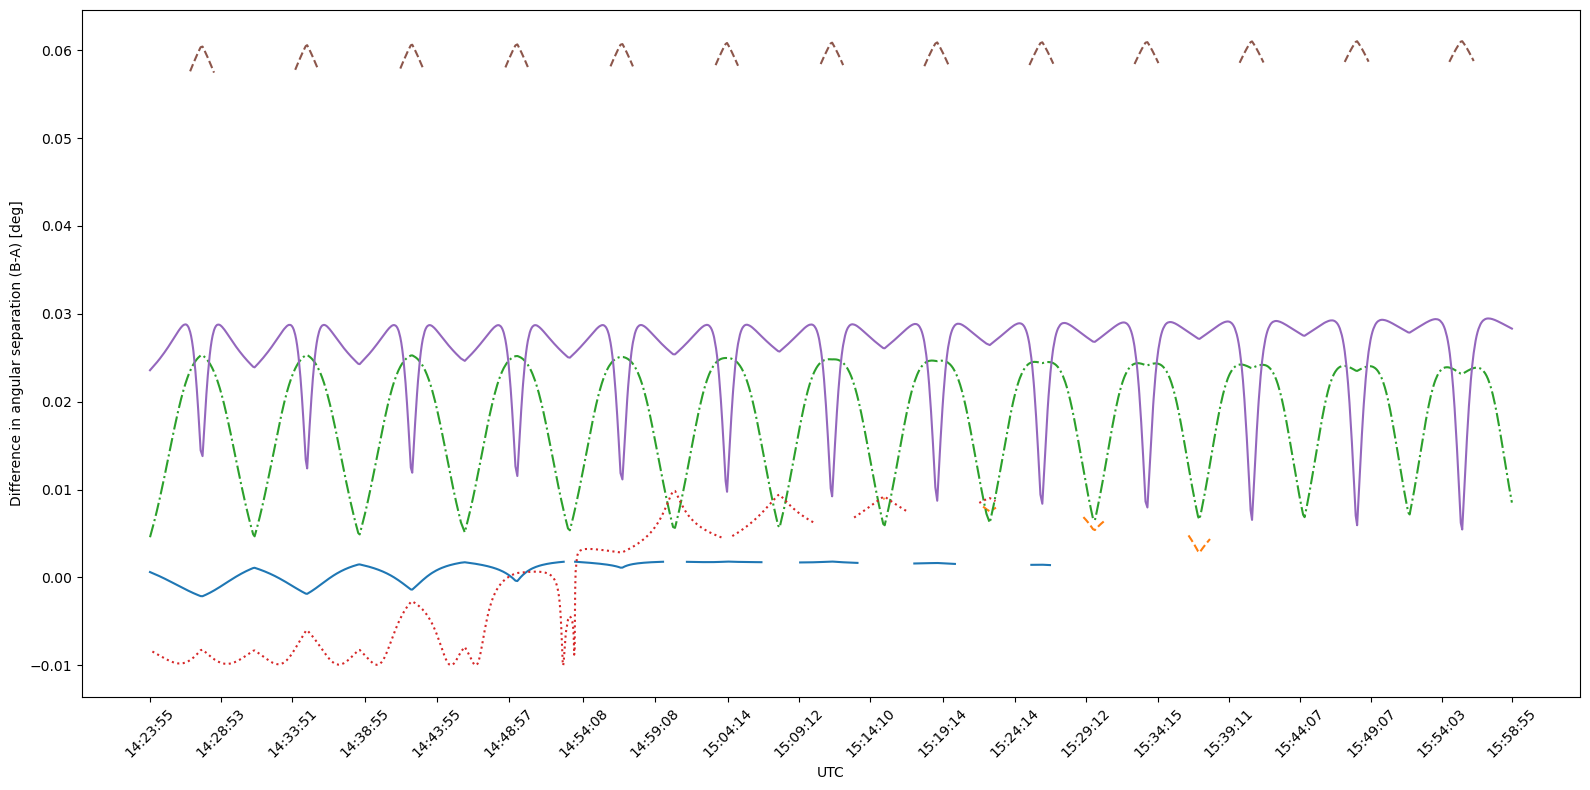

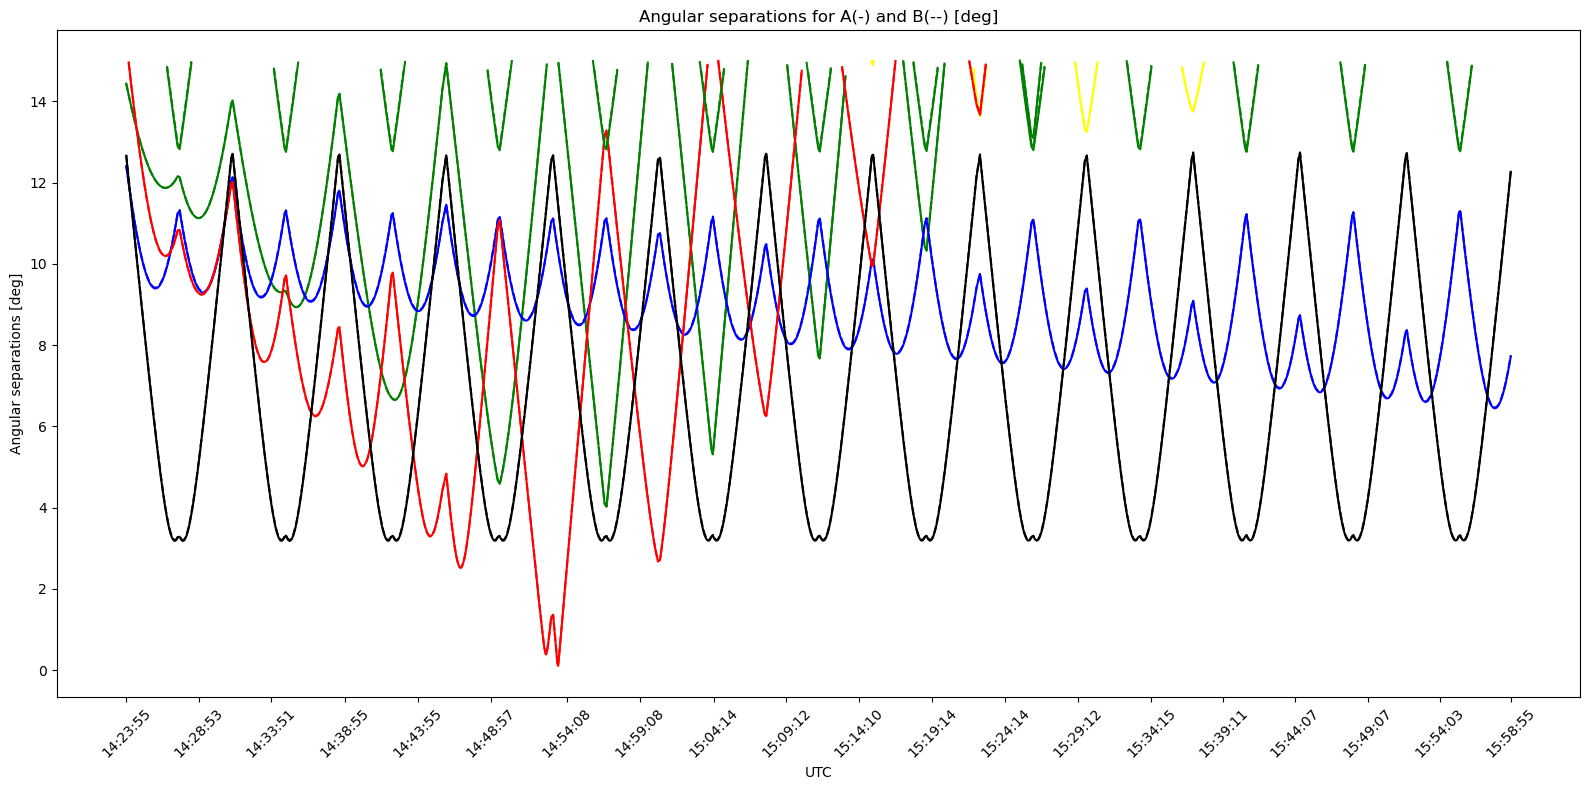

In [46]:
# generating information for 10 days
N = 10
source_older = int((TODAY - timedelta(days=N)).timestamp())
sats_older = CS.retrieve_sats(params,source_older)
sats_older2 = CS.check_above_horizon(sats_older, MK_times, MK_location, params)
sats_older3 = CS.check_within_cutoff(sats_older2, MK_times, MK_az, MK_alt, MK_location, params)
angles_older = CS.plot_angular_separations(sats_older3, MK_times, MK_az, MK_alt, MK_location, params)
angles_diff = CS.plot_different_sources(angles, angles_older, MK_times, params)
CS.plot_different_sources2(angles, angles_older, MK_times, params)

#### 30 days

SATCAT for 'gnss' already exist!
Number of 'gnss' satellites: 172.
GPs for 'gnss' at 2026-08-18 already exist!
Number of 'gnss' satellites: 159.
Checking satellites above the horizon...
	Number of satellites above horizon: 77
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 82
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 5
	Number of satellites removed: 72


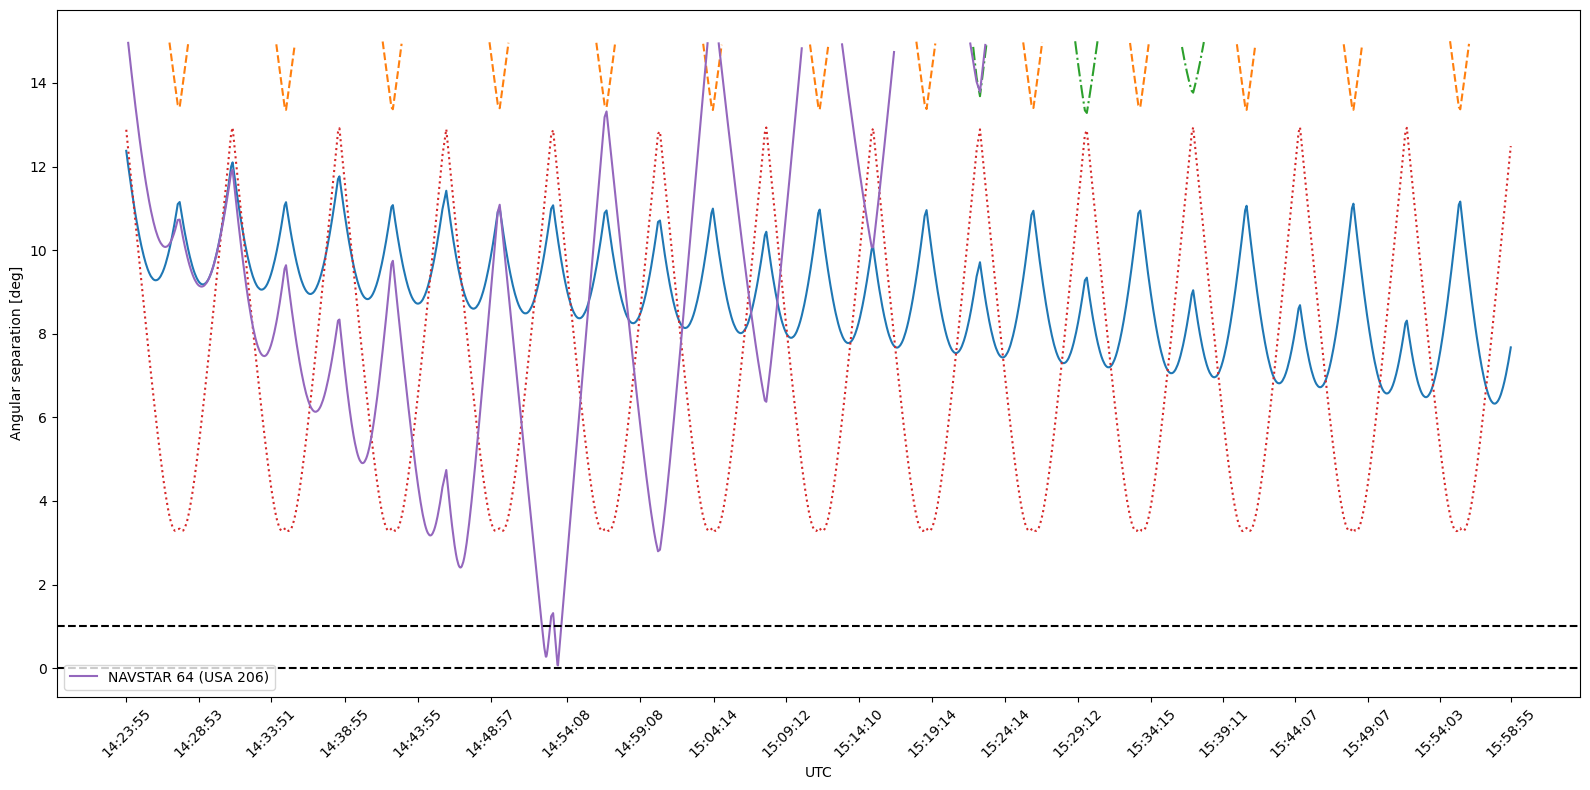

Only in angles: GALILEO 21 (2C7)


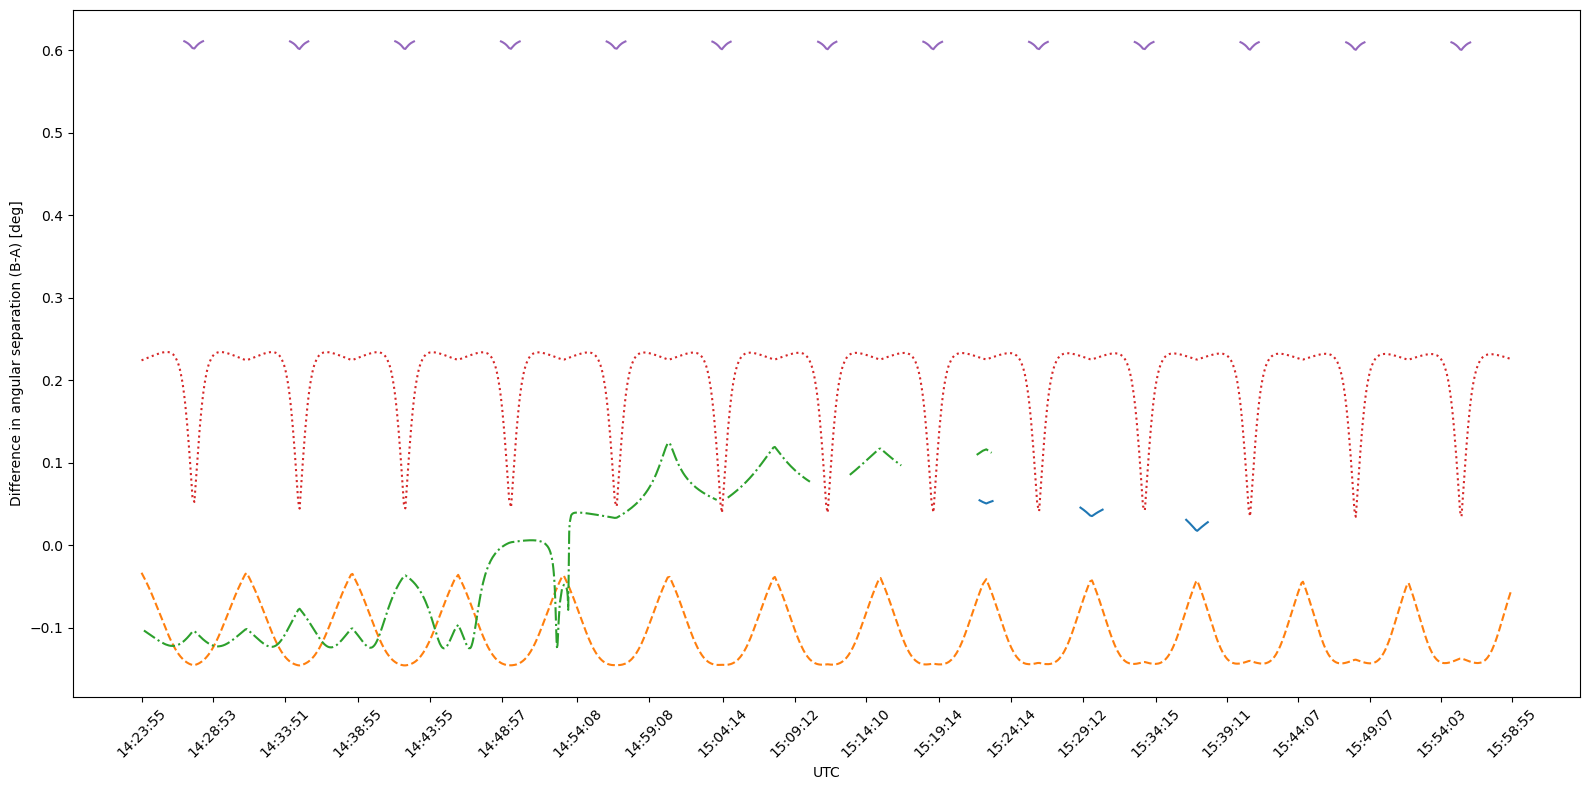

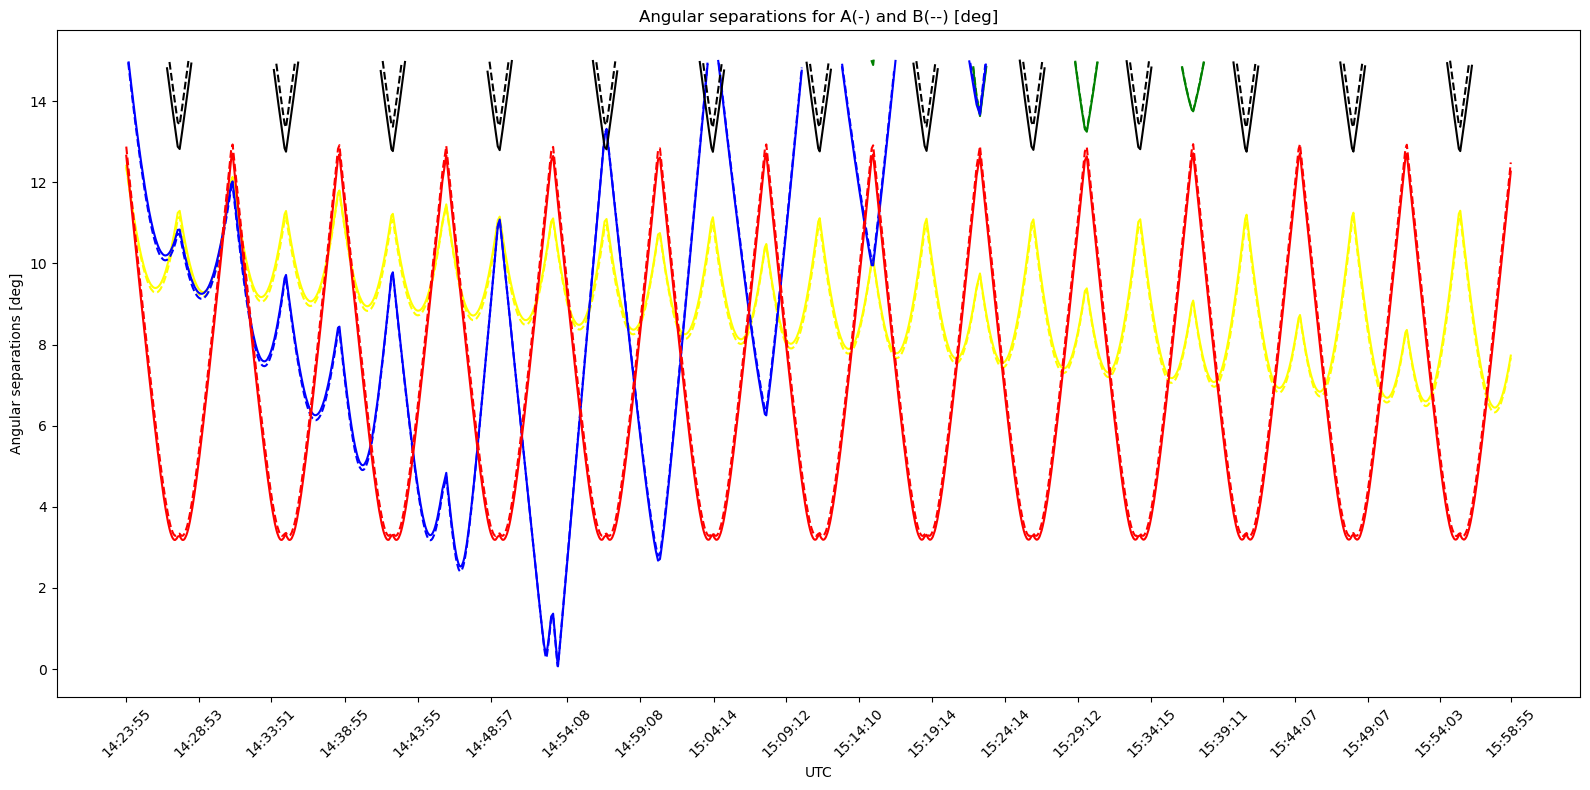

In [49]:
# generating information for 30 days
N = 30
source_older = int((TODAY - timedelta(days=N)).timestamp())
sats_older = CS.retrieve_sats(params,source_older)
sats_older2 = CS.check_above_horizon(sats_older, MK_times, MK_location, params)
sats_older3 = CS.check_within_cutoff(sats_older2, MK_times, MK_az, MK_alt, MK_location, params)
angles_older = CS.plot_angular_separations(sats_older3, MK_times, MK_az, MK_alt, MK_location, params)
angles_diff = CS.plot_different_sources(angles, angles_older, MK_times, params)
CS.plot_different_sources2(angles, angles_older, MK_times, params)

#### 90 days

SATCAT for 'gnss' already exist!
Number of 'gnss' satellites: 172.
GPs for 'gnss' at 2026-06-19 already exist!
Number of 'gnss' satellites: 168.
Checking satellites above the horizon...
	Number of satellites above horizon: 86
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 82
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 5
	Number of satellites removed: 81


No handles with labels found to put in legend.


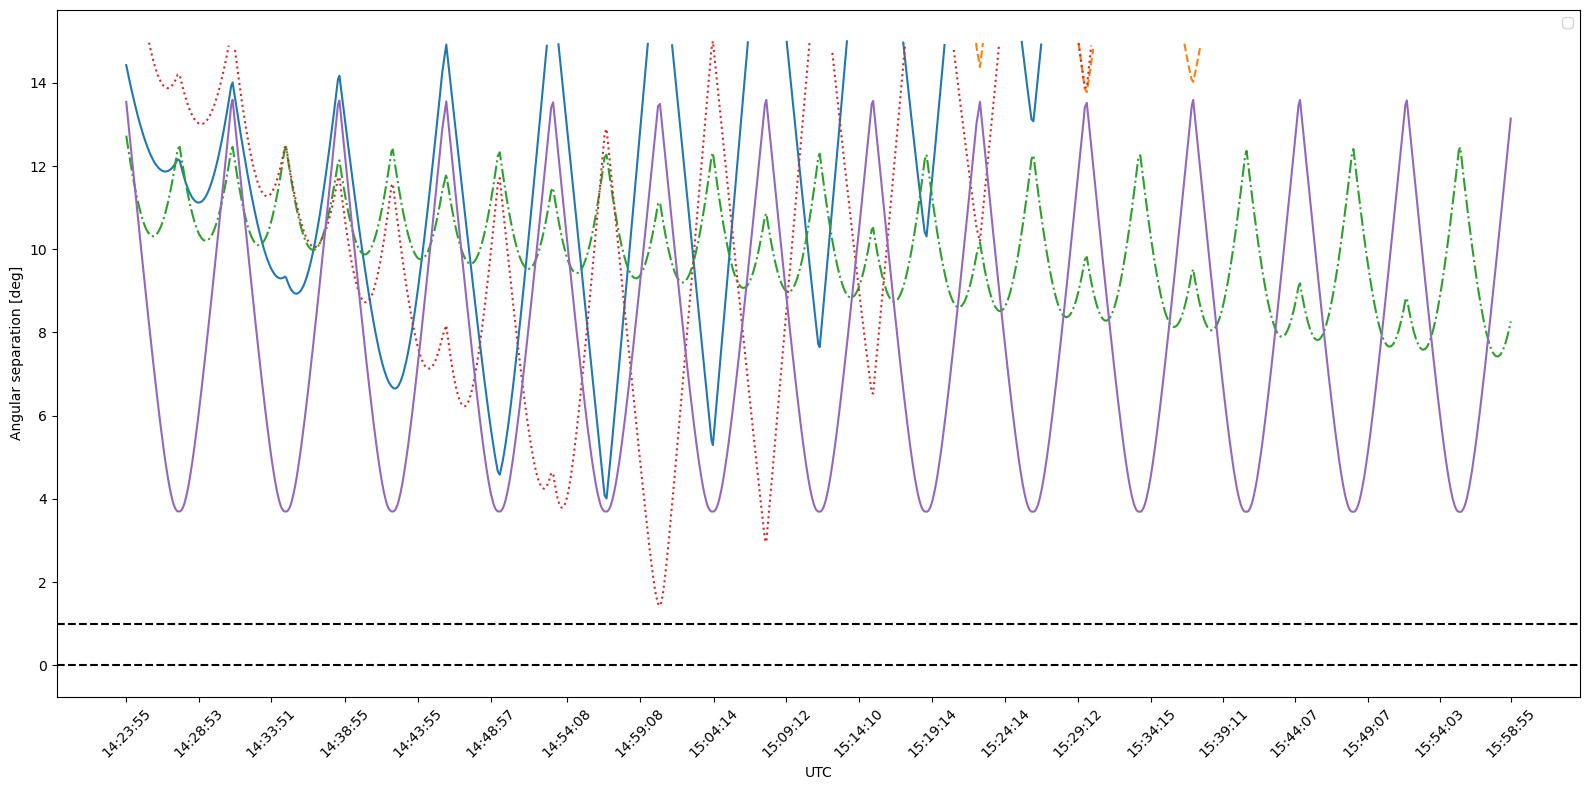

Only in angles: SES 5


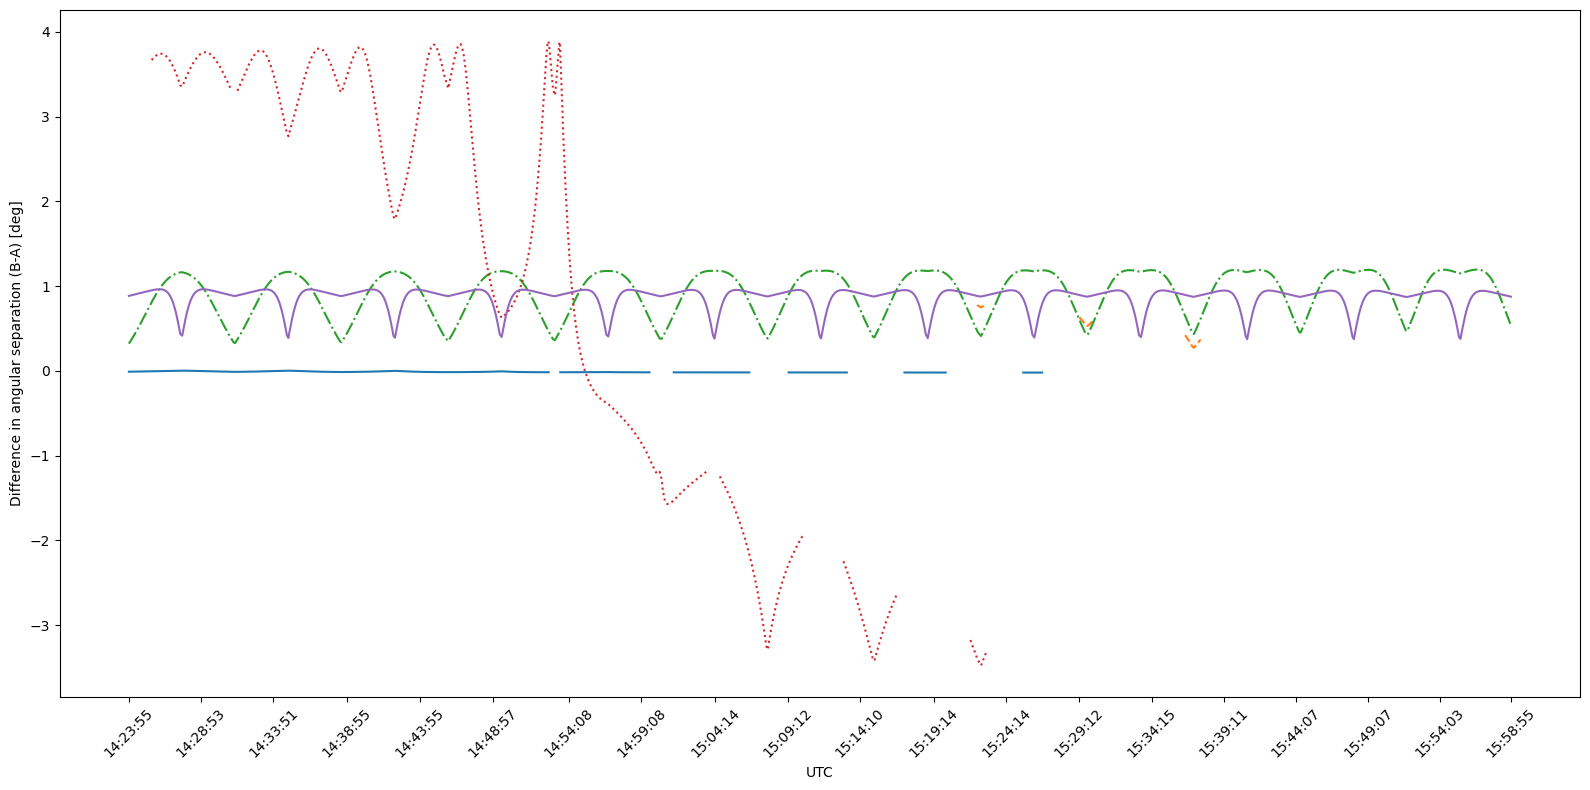

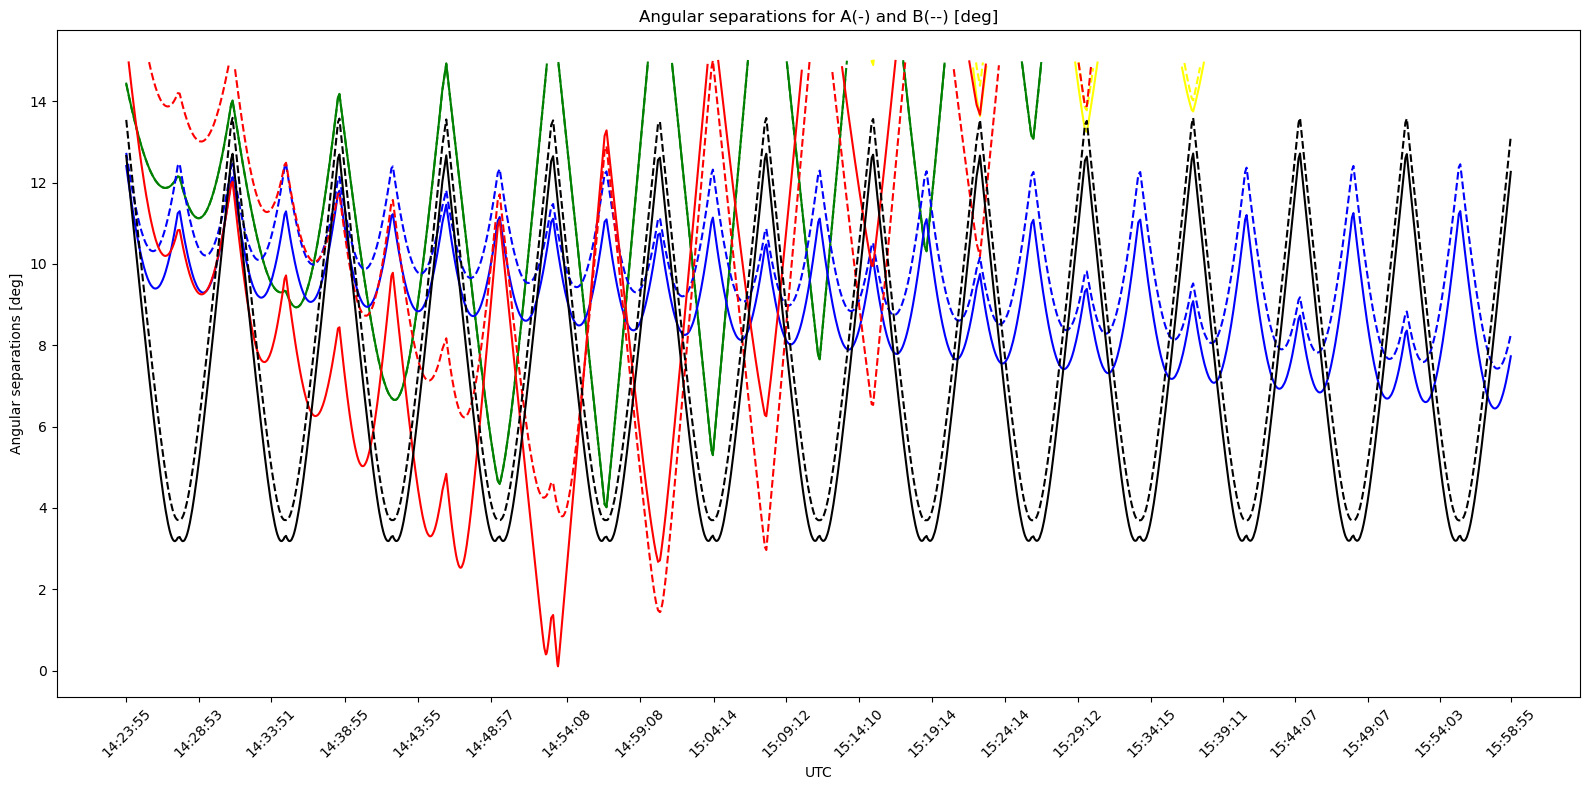

In [52]:
# generating information for 90 days
N = 90
source_older = int((TODAY - timedelta(days=N)).timestamp())
sats_older = CS.retrieve_sats(params,source_older)
sats_older2 = CS.check_above_horizon(sats_older, MK_times, MK_location, params)
sats_older3 = CS.check_within_cutoff(sats_older2, MK_times, MK_az, MK_alt, MK_location, params)
angles_older = CS.plot_angular_separations(sats_older3, MK_times, MK_az, MK_alt, MK_location, params)
angles_diff = CS.plot_different_sources(angles, angles_older, MK_times, params)
CS.plot_different_sources2(angles, angles_older, MK_times, params)

#### 180 days

SATCAT for 'gnss' already exist!
Number of 'gnss' satellites: 171.
Retrieving GPs for 'gnss' at 2026-03-21...
Number of 'gnss' satellites: 156.
Checking satellites above the horizon...
	Number of satellites above horizon: 84
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 72
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 5
	Number of satellites removed: 79


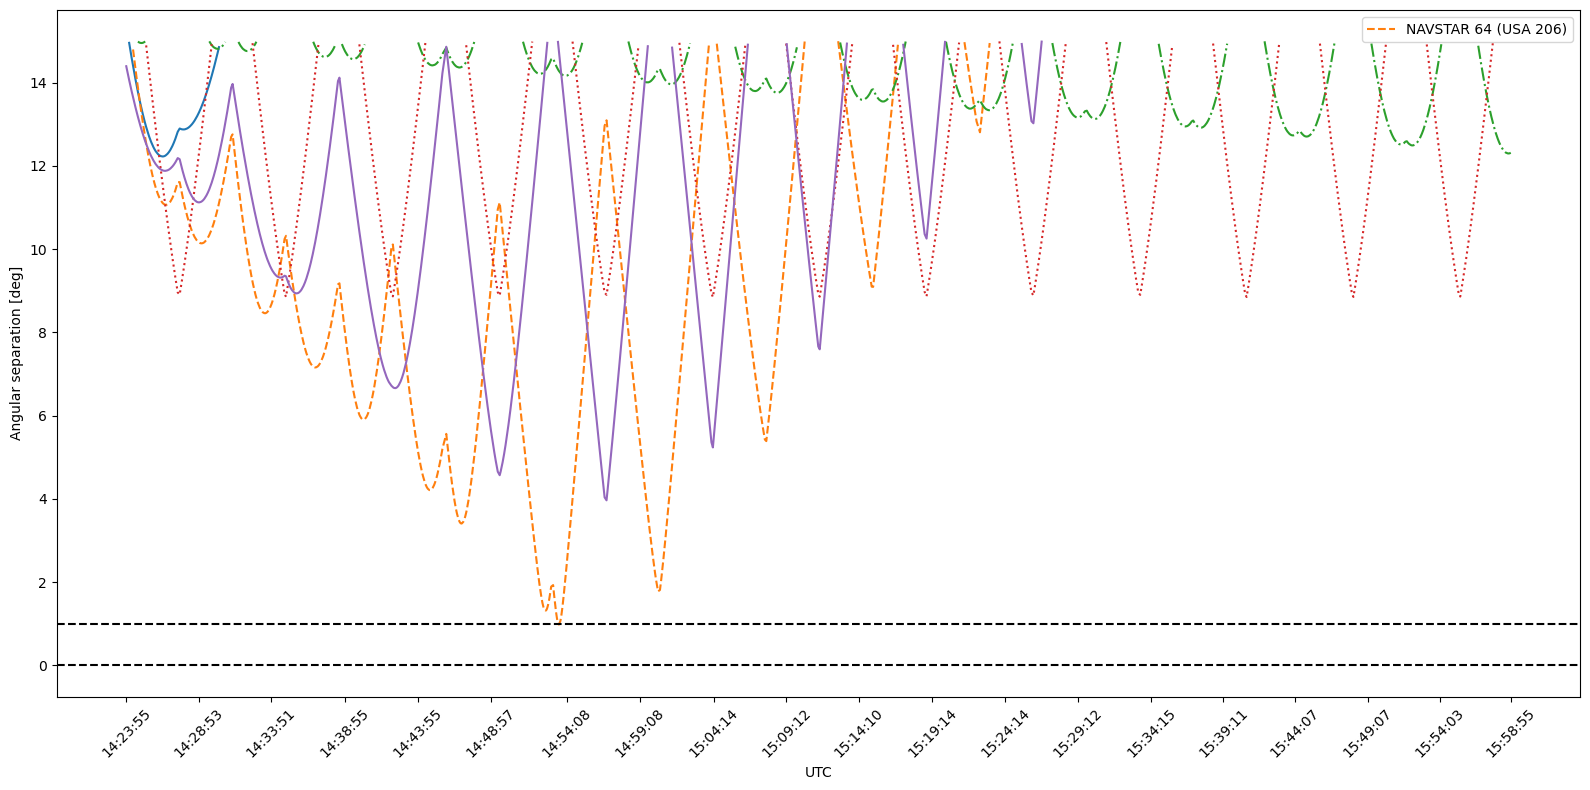

Only in angles: NAVSTAR 59 (USA 192)
Only in angles: SES 5
Only in angles_older: NAVSTAR 84 (USA 545)


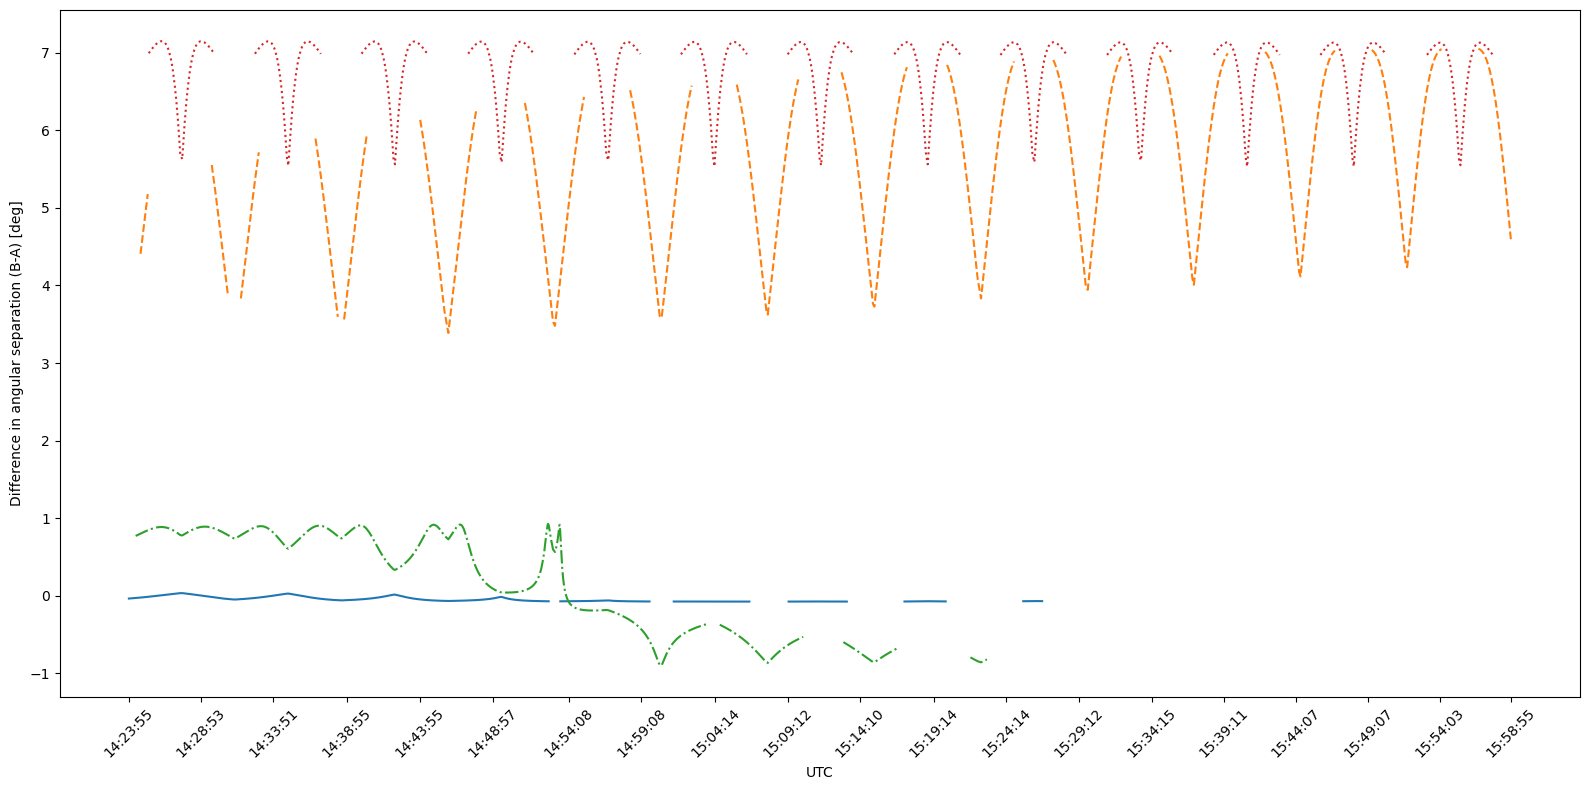

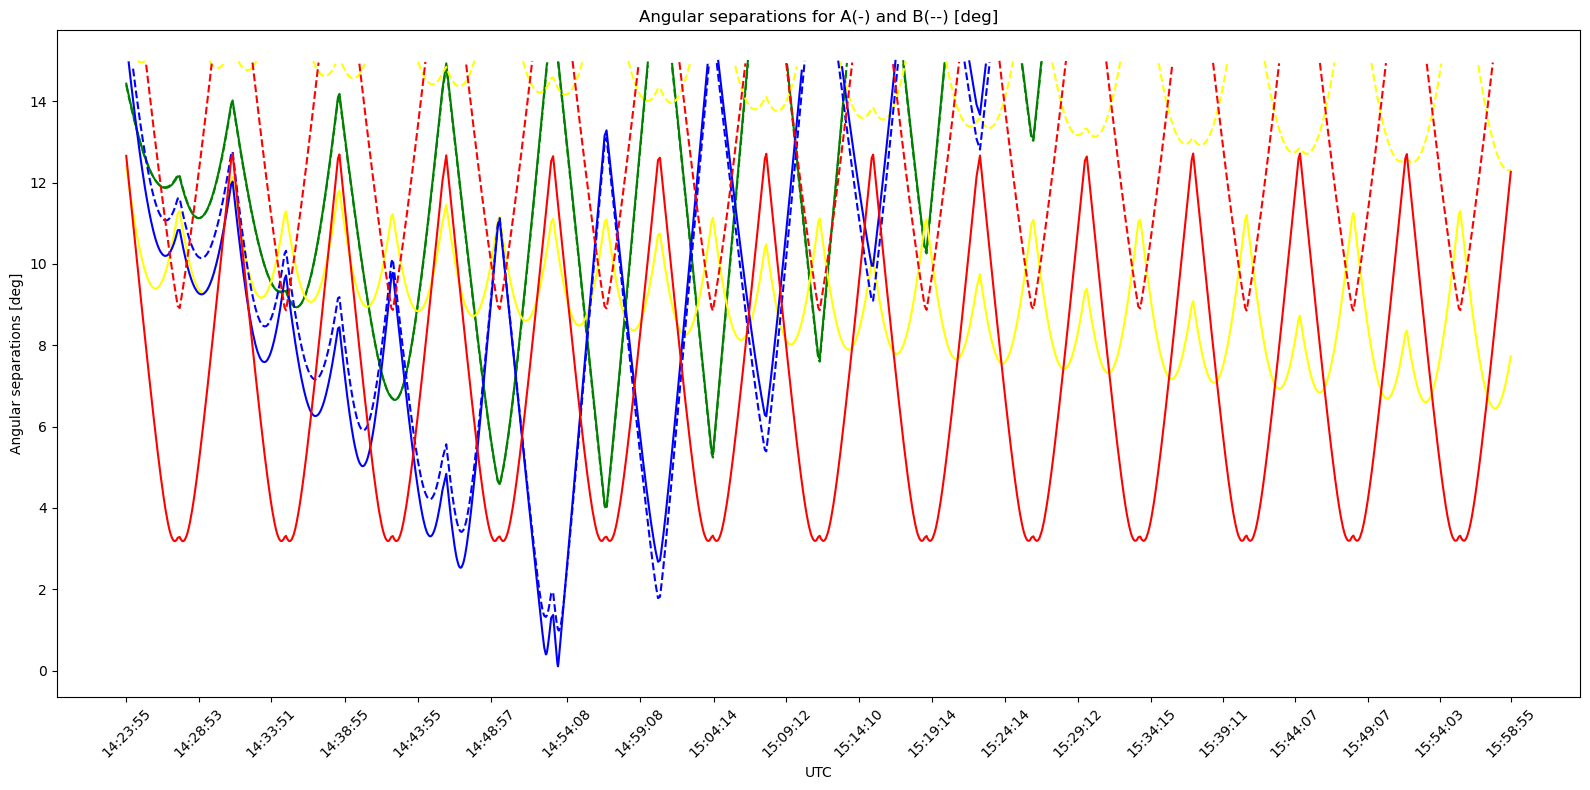

In [53]:
# generating information for 30 days
N = 180
source_older = int((TODAY - timedelta(days=N)).timestamp())
sats_older = CS.retrieve_sats(params,source_older)
sats_older2 = CS.check_above_horizon(sats_older, MK_times, MK_location, params)
sats_older3 = CS.check_within_cutoff(sats_older2, MK_times, MK_az, MK_alt, MK_location, params)
angles_older = CS.plot_angular_separations(sats_older3, MK_times, MK_az, MK_alt, MK_location, params)
angles_diff = CS.plot_different_sources(angles, angles_older, MK_times, params)
CS.plot_different_sources2(angles, angles_older, MK_times, params)